## Phase 1 — Data Loading & Path Setup

We begin by mounting Google Drive and defining paths to all 8 datasets collected
from FAO, World Bank, NASA, UNICEF, and Kaggle sources. This ensures every
subsequent notebook can reference data from a single consistent location.

In [1]:
# from google.colab import drive  # removed for local run
# drive.mount('/content/drive')  # removed for local run
import os

BASE = '../../FoodSafety_Malnutrition'

PATHS = {
    'malnutrition'   : f'{BASE}/data/tabular/malnutrition-estimates.csv',
    'country_avg'    : f'{BASE}/data/tabular/country-wise-average.csv',
    'poverty_data'   : f'{BASE}/data/tabular/PovStatsData.csv',
    'poverty_country': f'{BASE}/data/tabular/PovStatsCountry.csv',
    'rainfall'       : f'{BASE}/data/tabular/district wise rainfall normal.csv',
    'crop'           : f'{BASE}/data/tabular/crop_production.csv',
    'india_dhs'      : f'{BASE}/data/tabular/data.csv',
    'unicef_jme'     : f'{BASE}/data/tabular/JME_Country_Estimates_April_2021.xlsx',
    'zero_hunger'    : f'{BASE}/data/text/Zero_Hunger.xlsx',
}

for name, path in PATHS.items():
    status = "found" if os.path.exists(path) else "MISSING"
    print(f"{name:20s} → {status}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
malnutrition         → found
country_avg          → found
poverty_data         → found
poverty_country      → found
rainfall             → found
crop                 → found
india_dhs            → found
unicef_jme           → found
zero_hunger          → found


## Phase 1 — Loading All Datasets

Each dataset covers a different dimension of food security — nutrition outcomes, poverty levels, crop yield, rainfall patterns, and district-level survey data from India.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)

df_malnutrition = pd.read_csv(PATHS['malnutrition'])
df_country_avg  = pd.read_csv(PATHS['country_avg'])
df_poverty      = pd.read_csv(PATHS['poverty_data'])
df_pov_country  = pd.read_csv(PATHS['poverty_country'])
df_rainfall     = pd.read_csv(PATHS['rainfall'])
df_crop         = pd.read_csv(PATHS['crop'])
df_india        = pd.read_csv(PATHS['india_dhs'])
df_unicef       = pd.read_excel(PATHS['unicef_jme'], sheet_name='Survey Estimates')
df_text         = pd.read_excel(PATHS['zero_hunger'], sheet_name=0)

datasets = {
    'Malnutrition Estimates' : df_malnutrition,
    'Country Averages'       : df_country_avg,
    'World Bank Poverty'     : df_poverty,
    'India Rainfall'         : df_rainfall,
    'Crop Production'        : df_crop,
    'India DHS Survey'       : df_india,
    'UNICEF JME'             : df_unicef,
    'Zero Hunger Text'       : df_text,
}

for name, df in datasets.items():
    missing_pct = round(df.isnull().mean().mean() * 100, 1)
    print(f"{name:28s} | {df.shape[0]:>7,} rows | {df.shape[1]:>3} cols | {missing_pct:>5}% missing")

Malnutrition Estimates       |     924 rows |  20 cols |   6.1% missing
Country Averages             |     152 rows |   8 cols |   1.6% missing
World Bank Poverty           |   8,140 rows |  50 cols |  81.7% missing
India Rainfall               |     641 rows |  19 cols |   0.0% missing
Crop Production              | 246,091 rows |   7 cols |   0.2% missing
India DHS Survey             |  14,338 rows | 117 cols |  63.7% missing
UNICEF JME                   |     997 rows |  29 cols |  10.4% missing
Zero Hunger Text             |   3,500 rows |   4 cols |   1.9% missing


## Observation

All datasets loaded successfully. World Bank Poverty (81.7%) and India DHS Survey (63.7%)
show high missing values — expected from large multi-indicator survey datasets, will be
handled in the cleaning phase. Crop Production is our largest dataset at 246,091 rows
covering district-level agricultural data across India.

## Phase 1B — Initial Data Inspection

Before merging, we inspect each dataset individually to understand structure,
data types, value ranges and identify columns relevant to malnutrition forecasting.

In [3]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(f"{'─'*60}")
    print(df.head(3).to_string())


Malnutrition Estimates
────────────────────────────────────────────────────────────
   Unnamed: 0 ISO code      Country Survey Year  Year  Income Classification  LDC  LIFD  LLDC or SID2 Survey Sample (N)  Severe Wasting  Wasting  Overweight  Stunting  Underweight                Notes                                                                                                                           Report Author                                                                                                                                                                                    Source Short Source  U5 Population ('000s)
0           0      AFG  AFGHANISTAN        1997  1997                      0  1.0   1.0           1.0             4,846             NaN     18.2         6.5      53.2         44.9  Converted estimates                                                                                                                      CIET International  Afghanistan 1997 m

## Phase 1C — Selecting Relevant Columns

Each dataset has many columns we don't need. We extract only the columns
relevant to malnutrition forecasting and rename them to a consistent format
before merging.

In [4]:
malnutrition = df_malnutrition[['Country', 'Year', 'Stunting', 'Wasting', 'Underweight', 'Overweight']].copy()
malnutrition.columns = ['country', 'year', 'stunting', 'wasting', 'underweight', 'overweight']
malnutrition['country'] = malnutrition['country'].str.title()

country_avg = df_country_avg[['Country', 'Stunting', 'Wasting', 'Underweight']].copy()
country_avg.columns = ['country', 'stunting_avg', 'wasting_avg', 'underweight_avg']
country_avg['country'] = country_avg['country'].str.title()

rainfall = df_rainfall[['STATE_UT_NAME', 'DISTRICT', 'ANNUAL', 'Jun-Sep']].copy()
rainfall.columns = ['state', 'district', 'annual_rainfall', 'monsoon_rainfall']
rainfall['state']    = rainfall['state'].str.title()
rainfall['district'] = rainfall['district'].str.title()

crop = df_crop[['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Production']].copy()
crop.columns = ['state', 'district', 'year', 'season', 'crop', 'production']
crop['state']    = crop['state'].str.title()
crop['district'] = crop['district'].str.title()

india = df_india[['country', 'year', 'stunted', 'wasted', 'healthy', 'poorest', 'underweight_bmi']].copy()
india.columns = ['country', 'year', 'stunted', 'wasted', 'healthy', 'poorest', 'underweight']

unicef = df_unicef[['Country and areas', 'Year*', 'Stunting', 'Wasting', 'Underweight', 'UNICEF Region']].copy()
unicef.columns = ['country', 'year', 'stunting', 'wasting', 'underweight', 'region']
unicef['country'] = unicef['country'].str.title()

text_data = df_text.copy()
text_data.columns = ['country', 'code', 'year', 'undernourishment_pct']
text_data['country'] = text_data['country'].str.title()

print("Malnutrition   :", malnutrition.shape)
print("Country Avg    :", country_avg.shape)
print("Rainfall       :", rainfall.shape)
print("Crop           :", crop.shape)
print("India DHS      :", india.shape)
print("UNICEF         :", unicef.shape)
print("Text Data      :", text_data.shape)

Malnutrition   : (924, 6)
Country Avg    : (152, 4)
Rainfall       : (641, 4)
Crop           : (246091, 6)
India DHS      : (14338, 7)
UNICEF         : (997, 6)
Text Data      : (3500, 4)


## Phase 1D — Merging Datasets

We merge all tabular datasets into one unified dataframe. The merge key is
country and year. India-specific datasets (crop and rainfall) are merged
separately at district level and then joined to the main frame.

In [5]:
main = pd.merge(malnutrition, unicef[['country', 'year', 'region']],
                on=['country', 'year'], how='left')

main = pd.merge(main, country_avg, on='country', how='left')

main = pd.merge(main, text_data[['country', 'year', 'undernourishment_pct']],
                on=['country', 'year'], how='left')

print("Main merged dataframe :", main.shape)
print(main.head(3).to_string())

Main merged dataframe : (944, 11)
       country  year  stunting  wasting  underweight  overweight region  stunting_avg  wasting_avg  underweight_avg  undernourishment_pct
0  Afghanistan  1997      53.2     18.2         44.9         6.5     SA        47.775        10.35           30.375                   NaN
1  Afghanistan  2004      59.3      8.6         32.9         4.6     SA        47.775        10.35           30.375                  38.0
2  Afghanistan  2013      40.4      9.5         24.6         5.3     SA        47.775        10.35           30.375                  20.7


In [6]:
india_district = pd.merge(crop, rainfall, on=['state', 'district'], how='inner')

print("India district dataframe :", india_district.shape)
print(india_district.head(3).to_string())

India district dataframe : (164673, 8)
            state   district  year       season         crop  production  annual_rainfall  monsoon_rainfall
0  Andhra Pradesh  Anantapur  1997  Kharif         Arhar/Tur      2600.0            572.7             322.8
1  Andhra Pradesh  Anantapur  1997  Kharif             Bajra       500.0            572.7             322.8
2  Andhra Pradesh  Anantapur  1997  Kharif       Castor seed       100.0            572.7             322.8


In [7]:
print("Main dataframe — missing values per column")
print("─" * 45)
missing = main.isnull().sum()
missing = missing[missing > 0]
for col, val in missing.items():
    pct = round(val / len(main) * 100, 1)
    print(f"  {col:30s} : {val:>4} missing ({pct}%)")

print(f"\nIndia district — missing values : {india_district.isnull().sum().sum()}")

Main dataframe — missing values per column
─────────────────────────────────────────────
  stunting                       :   37 missing (3.9%)
  wasting                        :   47 missing (5.0%)
  underweight                    :   22 missing (2.3%)
  overweight                     :  137 missing (14.5%)
  region                         :  141 missing (14.9%)
  stunting_avg                   :    1 missing (0.1%)
  wasting_avg                    :    3 missing (0.3%)
  underweight_avg                :    3 missing (0.3%)
  undernourishment_pct           :  531 missing (56.2%)

India district — missing values : 2794


## Phase 1E — Handling Missing Values

We use median imputation for numerical columns and forward fill for
regional/categorical columns. The undernourishment column has 56% missing
because not all countries appear in the Zero Hunger text dataset — we fill
these using the country average stunting as a proxy.

In [8]:
num_cols = ['stunting', 'wasting', 'underweight', 'overweight',
            'stunting_avg', 'wasting_avg', 'underweight_avg']

for col in num_cols:
    main[col].fillna(main[col].median(), inplace=True)

main['region'].fillna('Unknown', inplace=True)

main['undernourishment_pct'].fillna(main.groupby('country')['undernourishment_pct']\
                             .transform('median'), inplace=True)
main['undernourishment_pct'].fillna(main['undernourishment_pct'].median(), inplace=True)

india_district['production'].fillna(india_district.groupby(['state', 'crop'])['production']\
                             .transform('median'), inplace=True)
india_district['production'].fillna(india_district['production'].median(), inplace=True)

print("Main dataframe — missing after cleaning  :", main.isnull().sum().sum())
print("India district — missing after cleaning  :", india_district.isnull().sum().sum())

Main dataframe — missing after cleaning  : 0
India district — missing after cleaning  : 0


In [9]:
print("Main dataframe final shape    :", main.shape)
print("India district final shape    :", india_district.shape)
print("\nMain dataframe dtypes")
print(main.dtypes)

Main dataframe final shape    : (944, 11)
India district final shape    : (164673, 8)

Main dataframe dtypes
country                  object
year                      int64
stunting                float64
wasting                 float64
underweight             float64
overweight              float64
region                   object
stunting_avg            float64
wasting_avg             float64
underweight_avg         float64
undernourishment_pct    float64
dtype: object


## Phase 1F — Saving Cleaned Dataframes

We save both cleaned dataframes to the processed folder in Google Drive.
These will be loaded directly in all subsequent notebooks — EDA, clustering,
classification and deep learning — without repeating the cleaning steps.

In [10]:
import os

PROCESSED = '../data/processed'
os.makedirs(PROCESSED, exist_ok=True)

main.to_csv(f'{PROCESSED}/main_merged.csv', index=False)
india_district.to_csv(f'{PROCESSED}/india_district.csv', index=False)

print("main_merged.csv     saved :", main.shape)
print("india_district.csv  saved :", india_district.shape)

main_merged.csv     saved : (944, 11)
india_district.csv  saved : (164673, 8)


## Phase 2 — Exploratory Data Analysis

We explore the merged dataset visually to understand distributions, trends,
correlations and outliers before building any model.

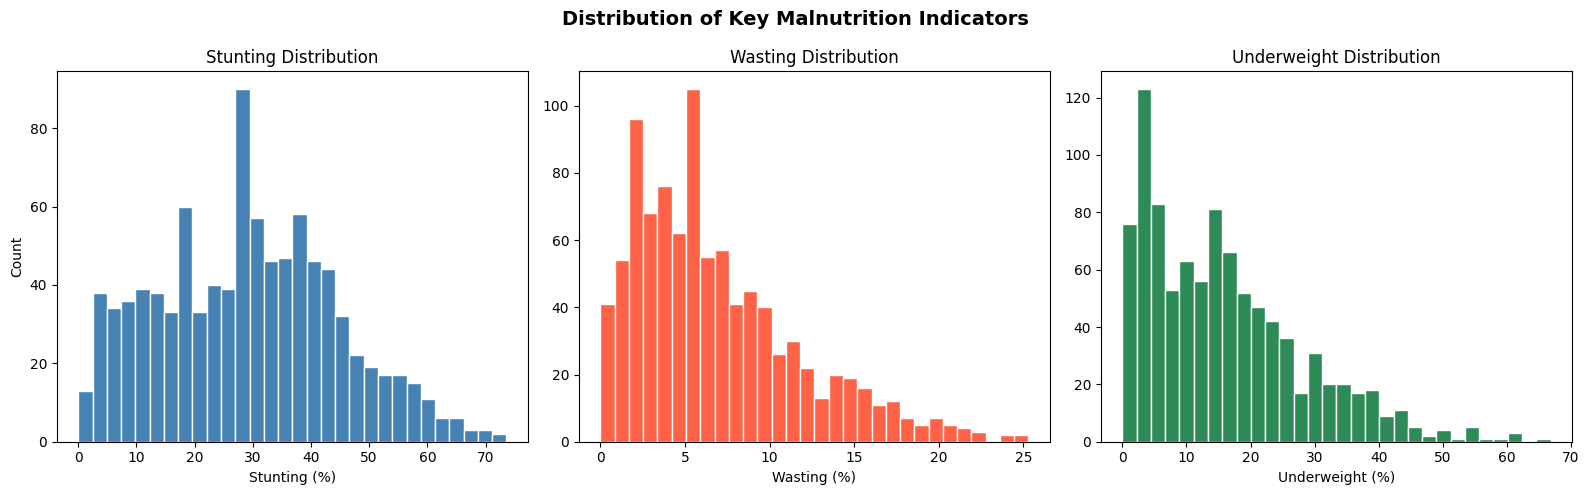

distributions.png saved


In [11]:
OUTPUTS = '../outputs/plots'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(main['stunting'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Stunting Distribution')
axes[0].set_xlabel('Stunting (%)')
axes[0].set_ylabel('Count')

axes[1].hist(main['wasting'].dropna(), bins=30, color='tomato', edgecolor='white')
axes[1].set_title('Wasting Distribution')
axes[1].set_xlabel('Wasting (%)')

axes[2].hist(main['underweight'].dropna(), bins=30, color='seagreen', edgecolor='white')
axes[2].set_title('Underweight Distribution')
axes[2].set_xlabel('Underweight (%)')

plt.suptitle('Distribution of Key Malnutrition Indicators', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/distributions.png', dpi=150)
plt.show()
print("distributions.png saved")

Stunting and underweight show right-skewed distributions meaning most countries
have moderate levels while a smaller group of countries carry extremely high
malnutrition burden. Wasting is more concentrated at lower values indicating
acute malnutrition is less widespread but still present in critical pockets.

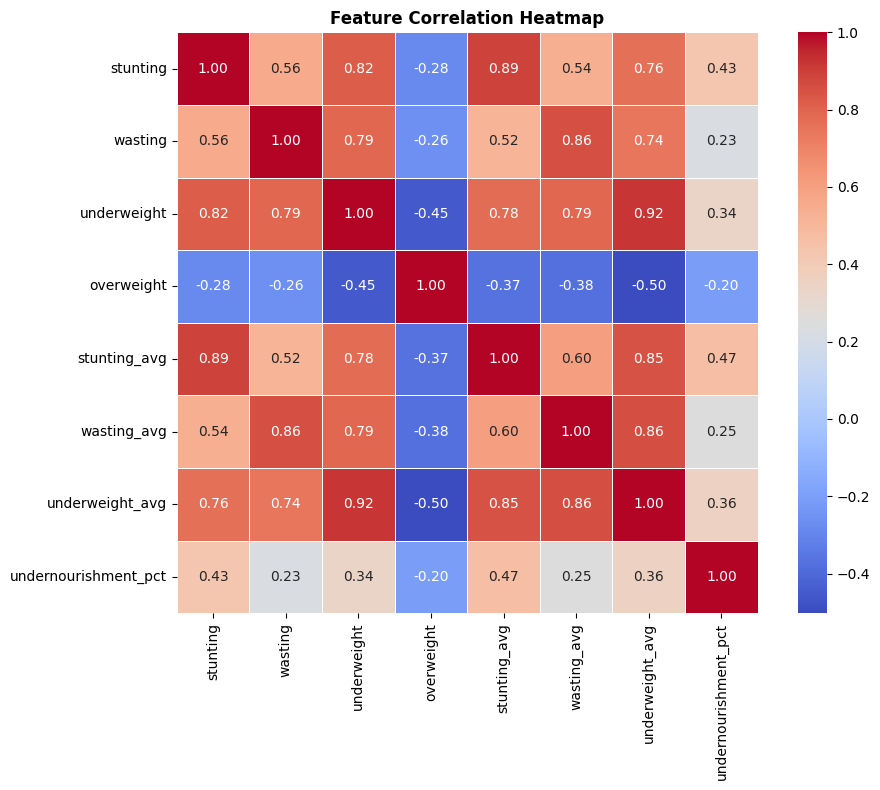

correlation_heatmap.png saved


In [12]:
num_features = ['stunting', 'wasting', 'underweight', 'overweight',
                'stunting_avg', 'wasting_avg', 'underweight_avg', 'undernourishment_pct']

corr = main[num_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/correlation_heatmap.png', dpi=150)
plt.show()
print("correlation_heatmap.png saved")

Stunting and underweight show strong positive correlation confirming they capture
overlapping dimensions of chronic malnutrition. Undernourishment percentage correlates
moderately with stunting and wasting validating its use as a key predictor feature.
Overweight shows negative correlation with wasting reflecting the nutritional divide
between wealthier and poorer nations.

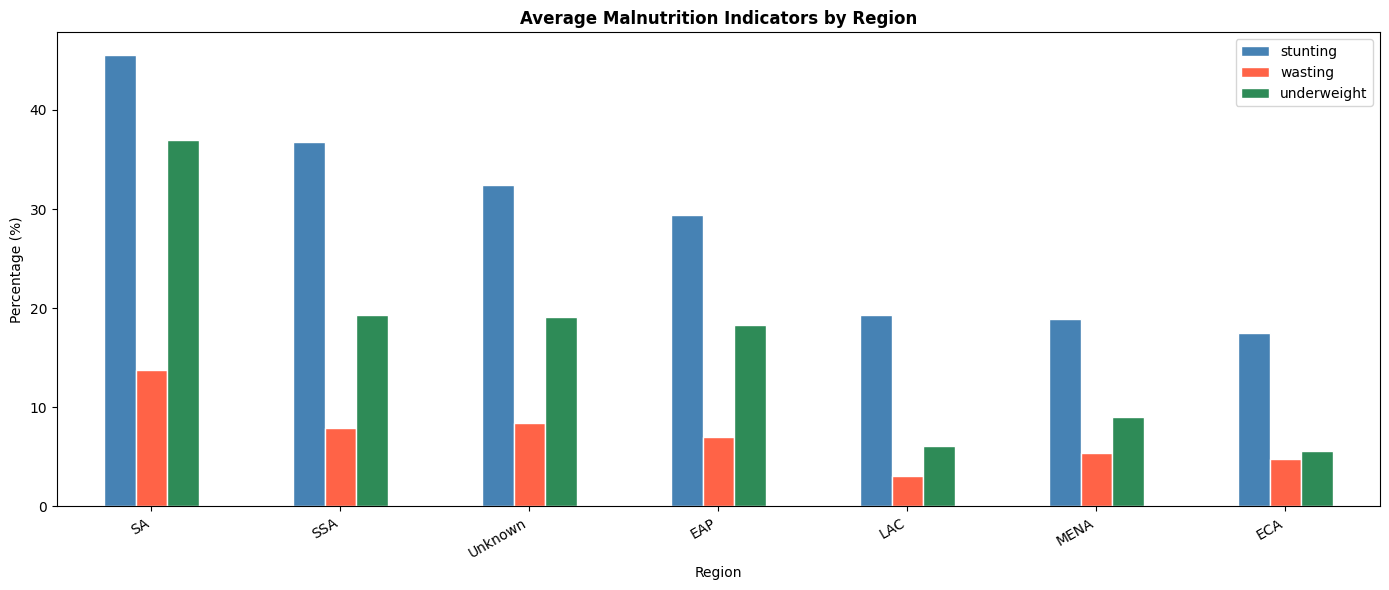

regional_analysis.png saved


In [13]:
region_data = main.groupby('region')[['stunting', 'wasting', 'underweight']].mean().round(2)
region_data = region_data.sort_values('stunting', ascending=False)

region_data.plot(kind='bar', figsize=(14, 6),
                 color=['steelblue', 'tomato', 'seagreen'], edgecolor='white')
plt.title('Average Malnutrition Indicators by Region', fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/regional_analysis.png', dpi=150)
plt.show()
print("regional_analysis.png saved")

South Asia and Sub-Saharan Africa show the highest malnutrition burden across all
three indicators. South Asia leads in stunting driven by countries like India,
Afghanistan and Bangladesh. This regional breakdown directly informs where our
early warning system should prioritize food aid deployment.

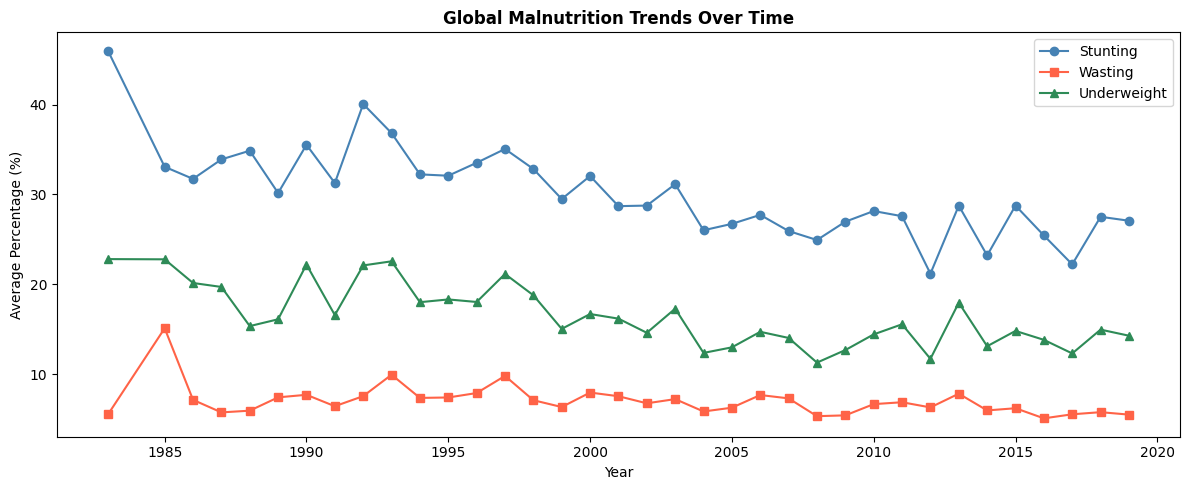

time_series_trends.png saved


In [14]:
yearly = main.groupby('year')[['stunting', 'wasting', 'underweight']].mean()

plt.figure(figsize=(12, 5))
plt.plot(yearly.index, yearly['stunting'], marker='o', color='steelblue', label='Stunting')
plt.plot(yearly.index, yearly['wasting'], marker='s', color='tomato', label='Wasting')
plt.plot(yearly.index, yearly['underweight'], marker='^', color='seagreen', label='Underweight')
plt.title('Global Malnutrition Trends Over Time', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Percentage (%)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/time_series_trends.png', dpi=150)
plt.show()
print("time_series_trends.png saved")

Global malnutrition indicators show a consistent declining trend over time reflecting
improvements in food security, healthcare and poverty reduction worldwide. However the
rate of decline has slowed in recent years highlighting the need for predictive systems
like ours to identify and target remaining high risk districts before crises occur.


## Summary — Notebook 1 Complete

Both cleaned dataframes have been saved to the processed folder and will be
loaded directly in all subsequent notebooks without repeating any cleaning steps.

Outputs saved:
- data/processed/main_merged.csv        →  944 rows, 11 features
- data/processed/india_district.csv     →  164,673 rows, 8 features
- outputs/plots/distributions.png       →  Malnutrition indicator distributions
- outputs/plots/correlation_heatmap.png →  Feature correlation heatmap
- outputs/plots/regional_analysis.png   →  Regional malnutrition comparison
- outputs/plots/time_series_trends.png  →  Global trends over time

Next → Notebook 2 covers Clustering and Classification on the processed data.